In [ ]:
!pip install fastai
!pip install gdown
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp310-cp310-linux_x86_64.whl size=550738 sha256=0837cc66ef3e8664fa3e10aba5664d4e5495493e9961df619351ab67549d020b
  Stored in directory: /root/.cache/pip/wheels/64/8a/da/f714bcf46c5efdcfcac0559e63370c21abe961c48e3992465a
Successfully built annoy


In [ ]:
!pip install ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import pickle
import gdown
import zipfile
import time
%matplotlib inline

from fastai.vision import *
from fastai.vision.all import *
from fastai.metrics import accuracy, top_k_accuracy
from google.colab import drive
from annoy import AnnoyIndex


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import requests
from io import BytesIO

In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
link = 'https://drive.google.com/uc?id=1j5fCPgh0gnY6v7ChkWlgnnHH6unxuAbb'
outcome = 'img.zip'
gdown.download(link, outcome)

link = 'https://drive.google.com/uc?id=1quO7Fck8MsKum4lzeyMSbbSbL6yGAIDJ'
outcome = 'list_category_img.txt'
gdown.download(link, outcome)

link = 'https://drive.google.com/uc?id=1d1nWNVHdIAvzuGyaSrajuPIffQTjbnsp'
outcome = 'list_category_cloth.txt'
gdown.download(link, outcome)

link = 'https://drive.google.com/uc?id=1_rg5_UZ-ZXkcg0yM_-PlN9yLtYT13sSx'
outcome = 'list_eval_partition.txt'
gdown.download(link, outcome)

root = './'
with zipfile.ZipFile("img.zip","r") as zip_ref:
    zip_ref.extractall(root)

Downloading...
From: https://drive.google.com/uc?id=1j5fCPgh0gnY6v7ChkWlgnnHH6unxuAbb
To: /content/img.zip
100%|██████████| 2.68G/2.68G [00:42<00:00, 62.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1quO7Fck8MsKum4lzeyMSbbSbL6yGAIDJ
To: /content/list_category_img.txt
100%|██████████| 21.4M/21.4M [00:00<00:00, 67.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1d1nWNVHdIAvzuGyaSrajuPIffQTjbnsp
To: /content/list_category_cloth.txt
100%|██████████| 882/882 [00:00<00:00, 1.59MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_rg5_UZ-ZXkcg0yM_-PlN9yLtYT13sSx
To: /content/list_eval_partition.txt
100%|██████████| 22.2M/22.2M [00:00<00:00, 97.3MB/s]


In [ ]:
categories = []
image_paths = []
data_types = []

# read category names
with open('list_category_cloth.txt', 'r') as f:
    lines = f.readlines()[2:]
    categories = [line.split()[0] for line in lines]

# read image paths and their corresponding categories
with open('list_category_img.txt', 'r') as f:
    lines = f.readlines()[2:]
    image_paths = [[word.strip() for word in line.split() if word] for line in lines]

# read data types (train, validation, or test) for each image
with open('list_eval_partition.txt', 'r') as f:
    lines = f.readlines()[2:]
    data_types = [[word.strip() for word in line.split() if word] for line in lines]

In [ ]:
# create a dictionary to hold image paths and their corresponding category numbers
img_dict = {"path": [], "category_id": []}

# iterate through the image paths and add them to the dictionary
for img_path, category in image_paths:
  img_dict["path"].append(img_path)
  img_dict["category_id"].append(int(category) - 1)

# create a DataFrame with image paths and their corresponding category numbers
df = pd.DataFrame(img_dict)

# merge the data types (train, validation, or test) with the DataFrame
df = df.merge(pd.DataFrame(data_types, columns=['path', 'data_type']), on='path')

# add a column with the category name based on the category number
df['category'] = df['category_id'].apply(lambda x: categories[x])

# drop the category number column
df = df.drop('category_id', axis=1)

# show the first few rows of the DataFrame
df.head()

,path,data_type,category
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,train,Blouse
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,train,Blouse
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,val,Blouse
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,train,Blouse
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,test,Blouse


In [ ]:
df[['path','data_type']].groupby('data_type').count()

,path
data_type,
test,40000
train,209222
val,40000


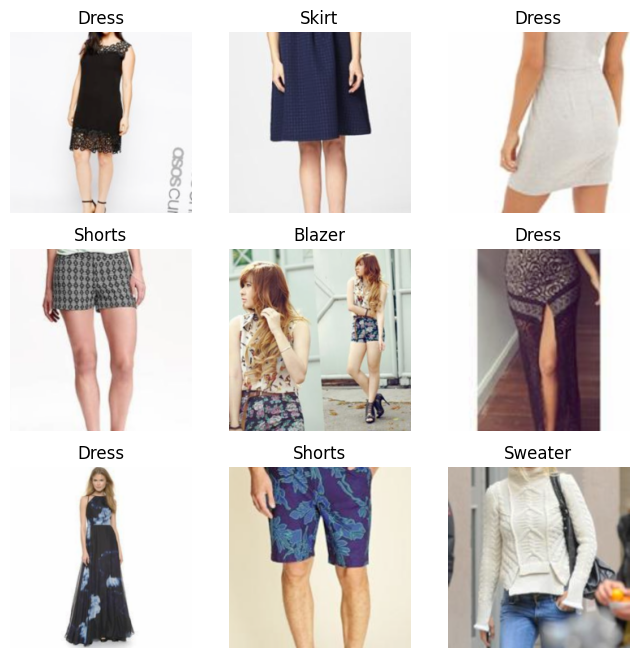

In [ ]:
dblock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   splitter=IndexSplitter(df[df['data_type'] == 'test'].index.tolist()),
                   get_x=ColReader('path', pref=root),
                   get_y=ColReader('category'),
                   item_tfms=[Resize(460)],
                   batch_tfms=[*aug_transforms(size=224, max_warp=0)]
                   )

# create dataloaders
dls = dblock.dataloaders(df, bs=128, num_workers=4, pin_memory=True)

# show batch
dls.show_batch(max_n=9, figsize=(8,8))


/usr/local/lib/python3.10/dist-packages/fastai/vision/learner.py:301: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 140MB/s]


epoch,train_loss,valid_loss,accuracy,top_k_accuracy,top_k_accuracy,time
0,1.496842,1.351850,0.600100,0.600100,0.899625,36:02


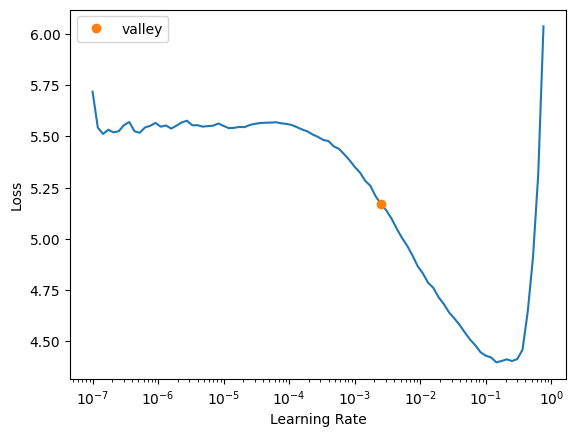

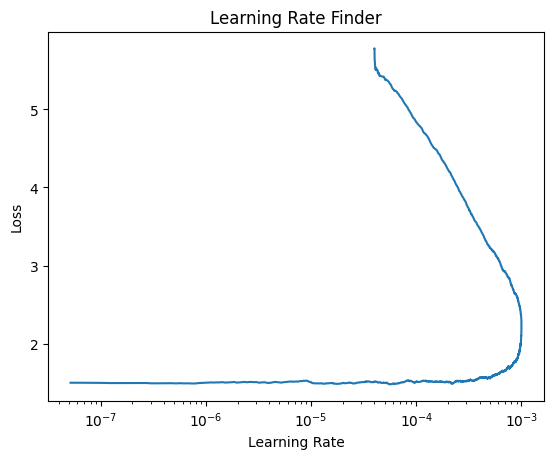

In [ ]:
resnet = models.resnet50 # or models.resnet18
model_accuracy = [accuracy, partial(top_k_accuracy, k=1), partial(top_k_accuracy, k=5)]


def resnet_model(dls, resnet, model_accuracy):
    learn = cnn_learner(dls, resnet, metrics=model_accuracy)
    learn.model = torch.nn.DataParallel(learn.model)
    learn.lr_find()
    learn.fit_one_cycle(1)

    learn.recorder.plot_lr_find()
    plt.xlabel('Learning Rate')
    plt.ylabel('Loss')
    plt.title('Learning Rate Finder')

    return learn

learn = resnet_model(dls, resnet, model_accuracy)

In [ ]:
learn.save('/content/gdrive/My Drive/resnet')

Path('/content/gdrive/My Drive/resnet.pth')

In [ ]:
def load_model(dls, resnet, model_accuracy, resnet_path):
  learn = cnn_learner(dls, resnet, metrics=model_accuracy)
  learn.model = torch.nn.DataParallel(learn.model)
  learn = learn.load(resnet_path)
  return learn

In [ ]:
resnet = models.resnet50(pretrained=True) # or models.resnet18
model_accuracy = [accuracy, partial(top_k_accuracy, k=1), partial(top_k_accuracy, k=5)]
resnet_path = '/content/gdrive/My Drive/resnet'

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 43.8MB/s]


In [ ]:
torch.save(resnet.state_dict(), '/content/gdrive/My Drive/resnet')

In [ ]:
state_dict = torch.load('/content/gdrive/My Drive/resnet')
resnet.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
class_interp = ClassificationInterpretation.from_learner(learn)

NameError: ignored

In [ ]:
class_interp.plot_confusion_matrix(figsize=(13,13))

NameError: ignored

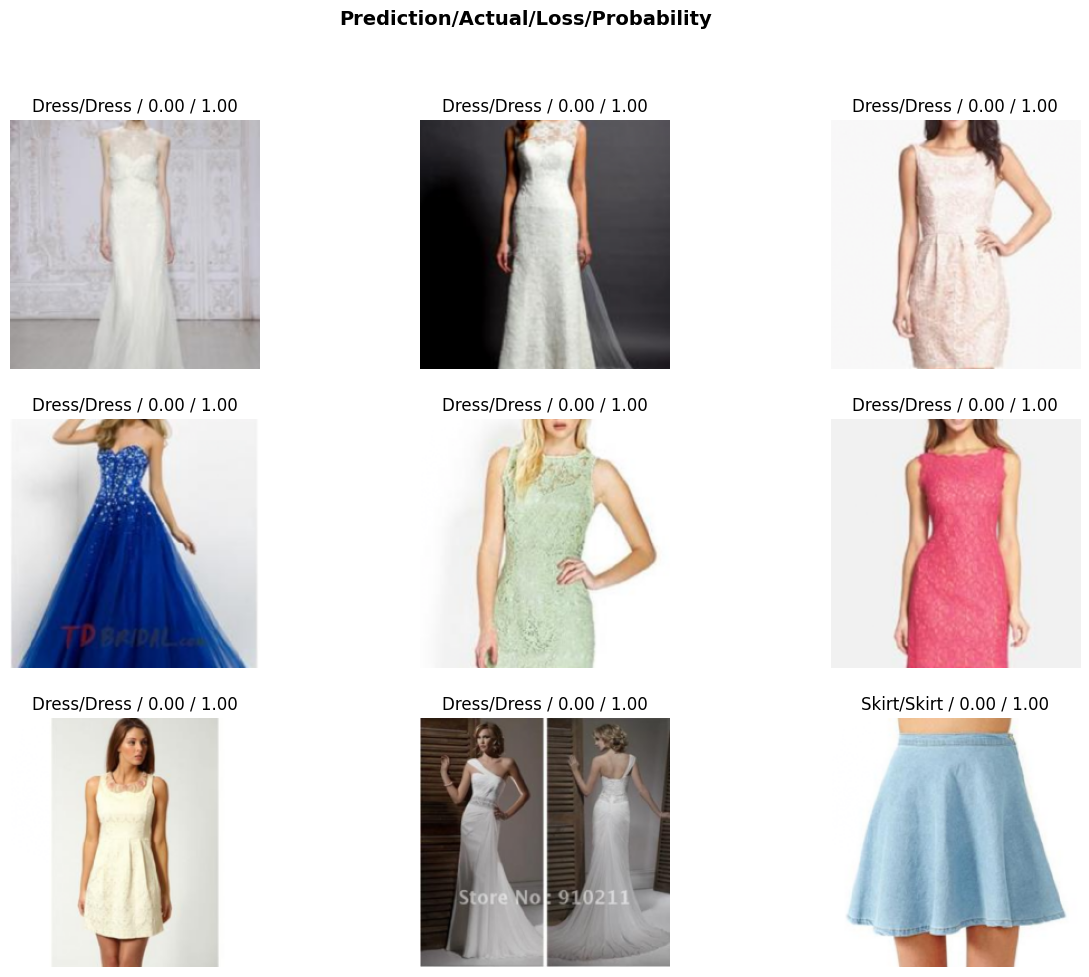

In [ ]:
class_interp.plot_top_losses(9, figsize=(15,11), largest=False)

In [ ]:
#learn.eval()

In [ ]:
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Annoy


In [ ]:
# create a transform to resize and normalize the images
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def generate_image_embedding(image_path):
    # Load the image and apply the transformation
    image = Image.open(image_path)
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0)

    # Generate the image embedding
    with torch.no_grad():
        embedding = resnet(image_tensor).squeeze().numpy()

    return embedding

In [ ]:
def generate_image_embedding(image_path, device="cpu"):
    # Load the image and apply the transformation
    image = Image.open(image_path)
    image_tensor = transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Generate the image embedding
    with torch.no_grad():
        # Move the model to the same device as the image tensor
        resnet.to(device)

        embedding = resnet(image_tensor).squeeze().cpu().numpy()

    return embedding


In [ ]:
import torch
from torchvision.models import resnet50
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
from torch.utils.data import DataLoader
from PIL import Image
import pandas as pd
from annoy import AnnoyIndex

# Function to generate image embeddings
def generate_image_embedding_batch(image_paths, model, device="cuda", batch_size=128):
    model.eval()
    model.to(device)

    embeddings = []
    with torch.no_grad():
        dataloader = DataLoader(image_paths, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
        for batch_paths in dataloader:
            batch_images = [Image.open(path).convert("RGB") for path in batch_paths]
            batch_images = [transform(image) for image in batch_images]
            batch_images = torch.stack(batch_images).to(device)

            # Generate the image embeddings
            embedding = model(batch_images).squeeze().cpu().numpy()
            embeddings.extend(embedding)

    return embeddings

# Efficient image transformation
transform = Compose([
    Resize(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Your existing code for loading data and creating the DataFrame

# Create a list of image paths
image_paths = df['path'].tolist()

# Generate image embeddings in batches
img_embeddings = generate_image_embedding_batch(image_paths, resnet50(pretrained=True), device="cuda" if torch.cuda.is_available() else "cpu")

# Create an approximate nearest neighbor index of the embeddings
index = AnnoyIndex(len(img_embeddings[0]), metric='euclidean')
for i, embedding in enumerate(img_embeddings):
    index.add_item(i, embedding)

# Build the index
index.build(n_trees=20)  # Adjust the number of trees as needed


True

In [ ]:
# Save the image embeddings
np.save('/content/gdrive/MyDrive/image_embeddings.npy', np.array(img_embeddings))

In [ ]:
# Save the Annoy index
index.save('/content/gdrive/MyDrive/annoy_index.ann')

True

In [ ]:
# Load the image embeddings
img_embeddings = np.load('/content/gdrive/MyDrive/image_embeddings.npy')

In [ ]:
# Load the Annoy index
index = AnnoyIndex(len(img_embeddings[0]), metric='euclidean')
index.load('/content/gdrive/MyDrive/annoy_index.ann')

True

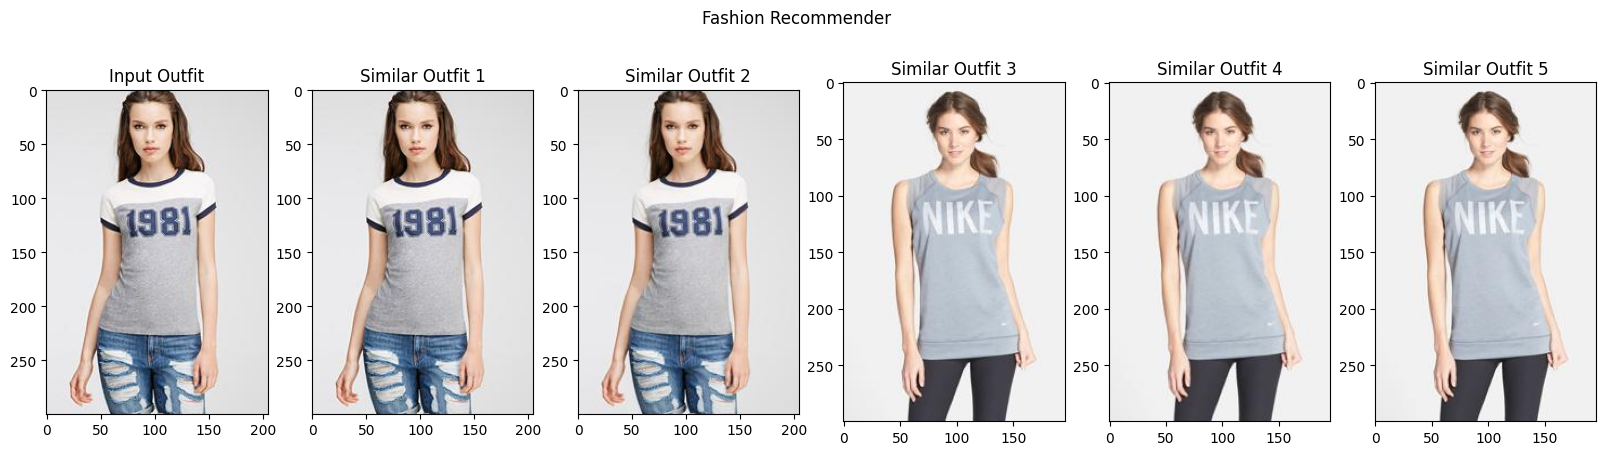

In [ ]:
def recommend_similar_outfits(image_path, n_recommendations=5):
    # Generate the embedding for the user input image
    input_embedding = generate_image_embedding(image_path)

    # Get the nearest neighbors of the input image embedding
    neighbor_ids = index.get_nns_by_vector(input_embedding, n_recommendations)

    # Get the corresponding image paths from the DataFrame
    similar_image_paths = df.iloc[neighbor_ids]['path'].tolist()

    # Display the input image and the similar images
    fig, axs = plt.subplots(1, n_recommendations+1, figsize=(20, 5))
    axs[0].imshow(Image.open(image_path))
    axs[0].set_title("Input Outfit")
    for i, path in enumerate(similar_image_paths):
        img = Image.open(path)
        axs[i+1].imshow(img)
        axs[i+1].set_title("Similar Outfit {}".format(i+1))
    plt.suptitle("Fashion Recommender")
    plt.show()

# Example usage:
image_path = '/content/img/1981_Graphic_Ringer_Tee/img_00000001.jpg'
recommend_similar_outfits(image_path, n_recommendations=5)

# Create file uploader and recommendation button
file_uploader = widgets.FileUpload(accept='image/*')
button = widgets.Button(description='Recommend')

FileUpload(value={}, accept='image/*', data=[b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00\x00\x01\x00\x01\x0…

Button(description='Recommend', style=ButtonStyle())

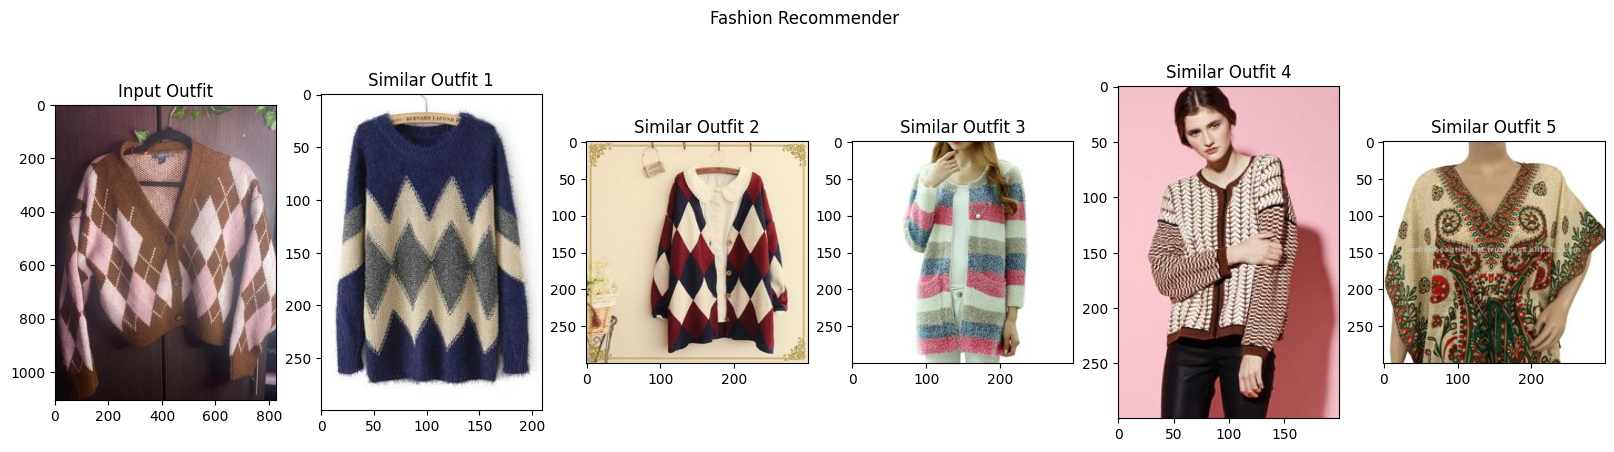

Please upload an image.


In [ ]:
# Define callback functions
def button_clicked(event):
    if file_uploader.value:
        uploaded_files = file_uploader.value

        if isinstance(uploaded_files, dict) and len(uploaded_files) > 0:
            file_key = next(iter(uploaded_files))
            file_info = uploaded_files[file_key]

            # Get the uploaded image file
            image_file = file_info['content']

            # Create a PIL image from the file
            image = Image.open(BytesIO(image_file))

            # Save the image to a temporary file
            temp_image_path = 'temp_image.jpg'
            image.save(temp_image_path, 'JPEG')

            # Call the recommend_similar_outfits function with the temporary image path
            recommend_similar_outfits(temp_image_path, n_recommendations=5)

            # Clear the file uploader
            file_uploader.value.clear()
        else:
            print('No files uploaded.')
    else:
        print('Please upload an image.')

# Attach the callback functions to the button
button.on_click(button_clicked)

# Display the file uploader and button
display(file_uploader, button)